<center><b>EE 533 Spring 2026<br>
Analog Circuits for Sensor Systems<br>
University of Washington Electrical & Computer Engineering</b></center>


<b>Instructor: Mahmood Hameed<br>
Assignment #4 (10 points)<br>
Due Monday, May 4 (Submit on Canvas as a Jupyter Notebook)</b> 

*Please show your work*

<b>Problem 1: Analysis of inverting and non-inverting amplifier structures

Most closed-loop amplifiers involving opamps are some variation on either the inverting or non-inverting amplifier. For this reason, it is import to be familiar with these structures and their characteristics. 

For the following, $R_1 = 1k\Omega$ and $R_2 = 9k\Omega$

For the opamp(s), DC open-loop gain $A_0 = 10^6 V/V$, open-loop input resistance $R_{in} \rightarrow \infty$, and open-loop output resistance $R_{out} = 1k\Omega$

<u>*DC Analysis*</u>

__a)__ Determine the *closed-loop* gain, input resistance, and output resistance for each (inverting and non-inverting) amplifier.

For the op amp I used the finite-gain model with an internal source

$$
v_x=A_0(v_+-v_-)
$$

and the given output resistance $R_o=1k\Omega$ in series with that source. The input current is zero because the open-loop input resistance is infinite.

For the non-inverting case,

$$
\beta=\frac{R_1}{R_1+R_2}, \qquad \alpha=\frac{R_1+R_2}{R_1+R_2+R_o}
$$

so

$$
\frac{v_{out}}{v_{in}}=\frac{\alpha A_0}{1+\alpha A_0\beta}.
$$

For the inverting case I solved the two node equations

$$
\frac{v_- - v_{in}}{R_1}+\frac{v_- - v_{out}}{R_2}=0
$$

$$
\frac{v_{out}+A_0v_-}{R_o}+\frac{v_{out}-v_-}{R_2}=0.
$$

For output resistance, I set the input source to zero and applied a test current at the output. Since the feedback network is the same small-signal network in both cases,

$$
R_{out,cl}=\left(\frac{1+A_0\beta}{R_o}+\frac{1}{R_1+R_2}\right)^{-1}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

R1=1e3
R2=9e3
A0=1e6
Ro=1e3

Rfb=R1+R2
beta=R1/Rfb
alpha=Rfb/(Rfb+Ro)

A_non=alpha*A0/(1+alpha*A0*beta)
Rout_cl=1/((1+A0*beta)/Ro+1/Rfb)

vin=1
M=np.array([
    [1/R1+1/R2, -1/R2],
    [A0/Ro-1/R2, 1/Ro+1/R2]
])
b=np.array([vin/R1, 0])
vminus,vout=np.linalg.solve(M,b)
A_inv=vout/vin
Rin_inv=vin/((vin-vminus)/R1)

print(f'non-inverting gain={A_non} V/V')
print(f'non-inverting Rin=infinite')
print(f'non-inverting Rout={Rout_cl} Ohm')
print()
print(f'inverting gain={A_inv} V/V')
print(f'inverting Rin={Rin_inv} Ohm')
print(f'inverting Rout={Rout_cl} Ohm')

non-inverting gain=9.999890001209986 V/V
non-inverting Rin=infinite
non-inverting Rout=0.009999890001209986 Ohm

inverting gain=-8.999900001099988 V/V
inverting Rin=1000.0099999899999 Ohm
inverting Rout=0.009999890001209986 Ohm


The final DC results are

$$
A_{v,noninv}=+9.99989\;V/V, \qquad R_{in,noninv}\rightarrow \infty, \qquad R_{out,noninv}\approx0.0100\Omega.
$$

$$
A_{v,inv}=-8.99990\;V/V, \qquad R_{in,inv}\approx1.00001k\Omega, \qquad R_{out,inv}\approx0.0100\Omega.
$$

These are basically the ideal values of $+10$ and $-9$, but with the small finite-$A_0$ correction included.

__b)__ If the opamp has a voltage offset $v_{os} = 1mV$ and input bias current $I_b = 1nA$, determine the total output offset voltage for each amplifier. It will be helpful to use superposition for this.

I treated the input offset voltage as a small voltage added at the non-inverting input. That means it is amplified by the noise gain, so both amplifier structures get the same offset contribution:

$$
v_{out,vos}\approx A_{v,noninv}v_{os}.
$$

For input bias current, I assumed the usual direction: $I_b$ flows into the op amp input pins. The $+$ input is driven by an ideal zero-ohm source when calculating output offset, so its bias current does not create an input voltage. The $-$ input bias current is supplied mainly through $R_2$, so the simple estimate is

$$
v_{out,Ib}\approx I_b R_2.
$$

In [2]:
vos=1e-3
Ib=1e-9

vout_vos=A_non*vos

M=np.array([
    [1/R1+1/R2, -1/R2],
    [A0/Ro-1/R2, 1/Ro+1/R2]
])
b=np.array([-Ib, 0])
vminus_b,vout_bias=np.linalg.solve(M,b)

vout_total=vout_vos+vout_bias

print(f'offset from vos={vout_vos} V')
print(f'offset from input bias current={vout_bias} V')
print(f'total output offset={vout_total} V')

offset from vos=0.009999890001209986 V
offset from input bias current=8.99990000109999e-06 V
total output offset=0.010008889901211087 V


So for both the inverting and non-inverting amplifier,

$$
v_{out,vos}\approx9.99989mV,
$$

$$
v_{out,Ib}\approx8.9999\mu V,
$$

and the total output offset is

$$
v_{out,offset}\approx 10.0089mV.
$$

The exact sign depends on the polarity of $v_{os}$ and the bias current convention. With positive $v_{os}$ at the $+$ input and bias current flowing into the $-$ input, the output offset is positive.

<b>Problem 2: Sensor amplification

The non-inverting amplifier structure has the advantage of high input impedance, making it suitable for interfacing with sensors with high output resistance.

Opamps have limits in terms of both output voltage and current that need to be considered when designing ampifier circuits.

For the sensor, $V_{S,DC} = 0V$ ($R_S$ is included for conceptual purposes only - it won't affect any of your calculations).

For the opamp, $A_0 = 10^6 V/V$, $f_t = 10 MHz$, open-loop input resistance $R_{in} \rightarrow \infty$, and open-loop output resistance $R_{out} = 0\Omega$


<u>*Design/Simulation*</u>

__a)__ Assuming an input signal range of $\pm 100mV$, design the amplifier (i.e. determine the gain) that maximizes the gain while ensuring the output voltage never exceeds 80% of the supply rails of $\pm 5V$.

Assuming the opamp has a maximum output current of $10mA$, determine minimum values for $R_1$ and $R_2$ to ensure the output current never exceeds 80% of the $10mA$ limit.

The output swing must stay within 80% of the $\pm5V$ rails, so the largest allowed output magnitude is

$$
0.8(5V)=4V.
$$

With an input range of $\pm100mV$, the maximum non-inverting gain is

$$
G=\frac{4V}{100mV}=40\;V/V.
$$

For a non-inverting amplifier,

$$
G=1+\frac{R_2}{R_1},
$$

so

$$
\frac{R_2}{R_1}=39.
$$

The output current limit is $10mA$, and we only want to use 80% of it:

$$
I_{out,max}=8mA.
$$

At the worst case $V_{out}=4V$, the feedback divider current is

$$
I=\frac{4V}{R_1+R_2}\le 8mA.
$$

So

$$
R_1+R_2\ge 500\Omega.
$$

Using $R_2=39R_1$ gives

$$
40R_1=500\Omega \Rightarrow R_1=12.5\Omega,
$$

$$
R_2=487.5\Omega.
$$

These are the minimum values. In a real circuit I would probably choose larger values to waste less current, but the minimum design is $R_1=12.5\Omega$ and $R_2=487.5\Omega$.

In [3]:
Vin_max=100e-3
Vrail=5
Vout_max=0.8*Vrail
G_ideal=Vout_max/Vin_max
I_limit=10e-3
I_allowed=0.8*I_limit
Rsum_min=Vout_max/I_allowed
R1_min=Rsum_min/G_ideal
R2_min=(G_ideal-1)*R1_min

print(f'G_ideal={G_ideal} V/V')
print(f'I_allowed={I_allowed*1e3} mA')
print(f'R1_min={R1_min} Ohm')
print(f'R2_min={R2_min} Ohm')
print(f'R1+R2={R1_min+R2_min} Ohm')

G_ideal=40.0 V/V
I_allowed=8.0 mA
R1_min=12.5 Ohm
R2_min=487.5 Ohm
R1+R2=500.0 Ohm


__b)__ Derive an expression for the closed-loop gain of the amplifier as a function of frequency. Plot the gain and phase of the amplifier using Python. Calculate the frequency at which the amplifier closed-loop gain becomes 1% lower than the ideal value calculated in *Part a*.

I used a one-pole open-loop model for the op amp:

$$
A(s)=\frac{A_0}{1+s/\omega_p},
$$

where

$$
f_p=\frac{f_t}{A_0}=\frac{10MHz}{10^6}=10Hz.
$$

The feedback factor for the gain-40 non-inverting amplifier is

$$
\beta=\frac{R_1}{R_1+R_2}=\frac{1}{40}.
$$

The closed-loop gain is

$$
H(s)=\frac{v_{out}}{v_s}=\frac{A(s)}{1+\beta A(s)}
$$

or

$$
H(s)=\frac{A_0}{1+A_0\beta+s/\omega_p}.
$$

So the low-frequency gain is slightly less than the ideal value:

$$
H(0)=\frac{A_0}{1+A_0\beta}=39.9984\;V/V.
$$

fp=10.0 Hz
low frequency gain=39.99840006399744 V/V
closed-loop pole=250010.0 Hz
1 percent drop target=39.6 V/V
f_1pct=35552.82074523135 Hz


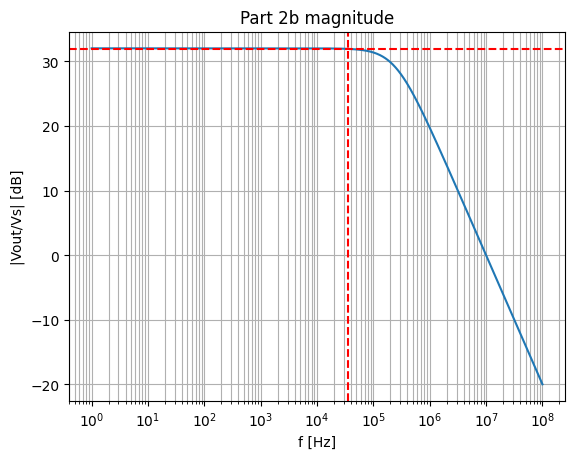

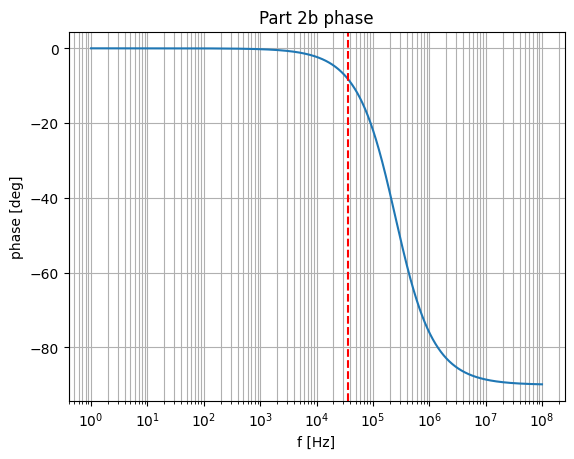

In [4]:
A0=1e6
ft=10e6
fp=ft/A0
G_ideal=40
beta=1/G_ideal

f=np.logspace(0,8,2001)
A=A0/(1+1j*f/fp)
H=A/(1+beta*A)
mag_db=20*np.log10(np.abs(H))
phase=np.angle(H,deg=True)

H0=A0/(1+A0*beta)
f_cl=fp*(1+A0*beta)
target=0.99*G_ideal
f_1pct=fp*math.sqrt((A0/target)**2-(1+A0*beta)**2)

print(f'fp={fp} Hz')
print(f'low frequency gain={H0} V/V')
print(f'closed-loop pole={f_cl} Hz')
print(f'1 percent drop target={target} V/V')
print(f'f_1pct={f_1pct} Hz')

plt.figure()
plt.semilogx(f,mag_db)
plt.axhline(20*np.log10(target),color='r',linestyle='--')
plt.axvline(f_1pct,color='r',linestyle='--')
plt.xlabel('f [Hz]')
plt.ylabel('|Vout/Vs| [dB]')
plt.title('Part 2b magnitude')
plt.grid(True,which='both')
plt.show()

plt.figure()
plt.semilogx(f,phase)
plt.axvline(f_1pct,color='r',linestyle='--')
plt.xlabel('f [Hz]')
plt.ylabel('phase [deg]')
plt.title('Part 2b phase')
plt.grid(True,which='both')
plt.show()

The gain becomes 1% lower than the ideal value of 40 V/V when

$$
|H(j2\pi f)|=0.99(40)=39.6\;V/V.
$$

From the calculation above,

$$
f_{1\%}\approx 35.6kHz.
$$

The closed-loop pole, or 3 dB bandwidth, is about

$$
f_{3dB}\approx250kHz.
$$

__c)__ Verify your design in LTspice using the *UniversalOpamp2* component. Show that your design meets the requirements by running an AC simulation with the DC value of $V_S$ set to $100mV$. Include a schematic showing the resistor values and DC node voltages along with your AC simulation results.

For LTspice I made a netlist for the single-stage design:

`Assignment4/sensor_amp_single.cir`

The circuit uses the same values from Part 2a:

$$
R_1=12.5\Omega, \qquad R_2=487.5\Omega.
$$

Use `UniversalOpamp2` with

```text
Avol=1Meg GBW=10Meg Slew=10Meg Ilimit=10m Rail=0 Vos=0 En=0 Enk=0 In=0 Ink=0 Rin=500Meg Rout=1
```

I used `Rout=1` only because the LTspice universal op amp model needs a nonzero value; this is close enough to the assignment's $R_{out}=0\Omega$ assumption.

The source should be

```text
DC 100m AC 1
```

so the `.op` point checks the worst positive output voltage and the AC magnitude of `V(out)/V(in)` is directly the closed-loop gain.

Expected `.op` values:

$$
V(in)=100mV, \qquad V(fb)\approx100mV, \qquad V(out)\approx4.0V.
$$

The feedback current is

$$
I=\frac{4V}{12.5\Omega+487.5\Omega}=8mA,
$$

which meets the 80% current requirement.

Expected AC results:

$$
|A_v|\approx40V/V=32.04dB \quad \text{at low frequency},
$$

$$
f_{1\%}\approx35.6kHz, \qquad f_{3dB}\approx250kHz.
$$

Detailed screenshot instructions are in `Assignment4/LTspice_steps.md`. The `.cir` file can verify the numbers, but for the assignment screenshot I still need to draw the schematic in LTspice and place `.op` data labels on the schematic.

__*Bonus* (1 point)__: Propose a design that achieves the same gain with at least 2x the bandwidth using the <u>same opamp specs</u>. Provide a schematic and AC simulation results that show your design achieves this.

To get the same gain with more bandwidth using the same op amp specs, I split the gain into two non-inverting stages.

The total gain should still be 40, so I set each stage to

$$
G_{stage}=\sqrt{40}=6.3246.
$$

For each stage,

$$
1+\frac{R_2}{R_1}=6.3246
$$

so

$$
\frac{R_2}{R_1}=5.3246.
$$

I chose

$$
R_1=1k\Omega, \qquad R_2=5.3246k\Omega
$$

for both stages. This keeps the feedback current much lower than the single-stage minimum-current design and still gives the same total voltage gain.

Gstage=6.324555320336759 V/V
R1_bonus=1000.0 Ohm
R2_bonus=5324.555320336759 Ohm
each stage closed-loop pole=1581148.8300841898 Hz
two-stage low frequency gain=39.99949404037432 V/V
two-stage f_1pct=158810.90131323723 Hz
two-stage f_3db=1017618.3000305702 Hz


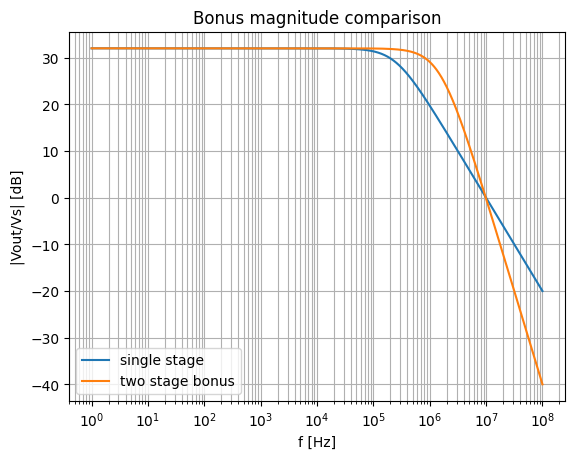

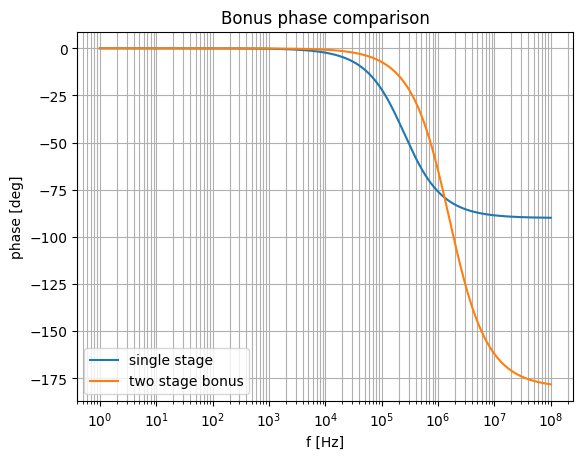

In [5]:
Gstage=math.sqrt(G_ideal)
beta_stage=1/Gstage
R1_bonus=1e3
R2_bonus=(Gstage-1)*R1_bonus

fcl_stage=fp*(1+A0*beta_stage)
Hstage0=A0/(1+A0*beta_stage)
Htotal0=Hstage0**2
f3db_bonus=fcl_stage*math.sqrt(math.sqrt(2)-1)
f1pct_bonus=fcl_stage*math.sqrt(Htotal0/(0.99*G_ideal)-1)

A_stage=A0/(1+1j*f/fp)
H_stage=A_stage/(1+beta_stage*A_stage)
H_bonus=H_stage**2

print(f'Gstage={Gstage} V/V')
print(f'R1_bonus={R1_bonus} Ohm')
print(f'R2_bonus={R2_bonus} Ohm')
print(f'each stage closed-loop pole={fcl_stage} Hz')
print(f'two-stage low frequency gain={Htotal0} V/V')
print(f'two-stage f_1pct={f1pct_bonus} Hz')
print(f'two-stage f_3db={f3db_bonus} Hz')

plt.figure()
plt.semilogx(f,20*np.log10(np.abs(H)),label='single stage')
plt.semilogx(f,20*np.log10(np.abs(H_bonus)),label='two stage bonus')
plt.xlabel('f [Hz]')
plt.ylabel('|Vout/Vs| [dB]')
plt.title('Bonus magnitude comparison')
plt.grid(True,which='both')
plt.legend()
plt.show()

plt.figure()
plt.semilogx(f,np.angle(H,deg=True),label='single stage')
plt.semilogx(f,np.angle(H_bonus,deg=True),label='two stage bonus')
plt.xlabel('f [Hz]')
plt.ylabel('phase [deg]')
plt.title('Bonus phase comparison')
plt.grid(True,which='both')
plt.legend()
plt.show()

The original single-stage design has

$$
f_{3dB}\approx250kHz.
$$

The two-stage design has

$$
f_{3dB}\approx1.02MHz,
$$

which is more than 4 times the single-stage bandwidth, so it satisfies the at-least-2x bonus requirement. Its 1% drop frequency is also about

$$
f_{1\%}\approx159kHz,
$$

which is more than 2 times the single-stage $35.6kHz$ value.

I also made the LTspice bonus netlist:

`Assignment4/sensor_amp_bonus_two_stage.cir`

The expected DC outputs with $V_s=100mV$ are

$$
V(mid)\approx0.632V, \qquad V(out)\approx4.0V.
$$